# Exploring report.csv

Open this notebook with:

```bash
uv run --with jupyter --with pandas --with matplotlib numpy jupyter notebook explore_report.ipynb
```

The CSV has two row types:
- **`file`** — one row per entity per cell (volumes, file sizes, instance counts)
- **`instance`** — one row per labelled object (metrics, distances)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

## Load

In [3]:
REPORT = "../data/results_betacells/report.csv"  # adjust path as needed

df = pd.read_csv(REPORT)

files = df[df.row_type == "file"].copy()
instances = df[df.row_type == "instance"].copy()

print(f"{len(df):,} rows total — {len(files)} file rows, {len(instances):,} instance rows")
print("cells   :", sorted(df.cell_id.dropna().unique()))
print("entities:", sorted(df.entity_name.unique()))

90,191 rows total — 57 file rows, 90,134 instance rows
cells   : ['high_c1', 'high_c2', 'high_c3', 'high_c4', 'low_c1', 'low_c2', 'low_c3']
entities: ['centrioles', 'cilium', 'golgi', 'granules', 'membrane', 'microtubules', 'mitochondria', 'nucleus', 'source']


## Example 1 — All files of a specific cell with their volumes

In [4]:
CELL = "high_c1"  # change to any cell_id

cell_files = (
    files[files.cell_id == CELL]
    .loc[:, ["entity_name", "entity_kind", "total_volume_um3", "instance_count", "file_size_bytes", "file_name"]]
    .sort_values("entity_kind")
)

display(cell_files)

,entity_name,entity_kind,total_volume_um3,instance_count,file_size_bytes,file_name
3,centrioles,label,0.042136,78.0,865895.0,high_c1_centrioles_mask.tif
82,golgi,label,33.566792,5146.0,2839575.0,high_c1_golgi_mask.tif
5229,granules,label,311.456723,9714.0,13098887.0,high_c1_granules_labels.tif
14944,microtubules,label,5.385554,1005.0,4566903.0,high_c1_microtubules_labels.tif
15950,mitochondria,label,102.158230,268.0,3050023.0,high_c1_mitochondria_mask.tif
1,membrane,mask,1515.706921,NaN,4356775.0,high_c1_membrane_mask.tif
2,nucleus,mask,189.452974,NaN,1558599.0,high_c1_nucleus_mask.tif
0,source,source,NaN,NaN,359222597.0,high_c1.tif


## Example 2 — Volumes of all entities across cells

In [5]:
pivot = (
    files[files.entity_kind != "source"]
    .pivot_table(index="entity_name", columns="cell_id", values="total_volume_um3")
)

display(pivot.style.format("{:.1f}"))

cell_id,high_c1,high_c2,high_c3,high_c4,low_c1,low_c2,low_c3
entity_name,,,,,,,
centrioles,0.0,0.1,0.0,0.0,0.0,0.0,0.0
cilium,nan,0.2,nan,nan,nan,nan,nan
golgi,33.6,26.6,18.1,18.8,26.7,11.8,12.7
granules,311.5,229.9,380.6,227.0,198.8,314.3,161.6
membrane,1515.7,1250.7,1347.5,1189.9,1197.8,1495.2,1390.7
microtubules,5.4,6.0,4.8,4.3,5.1,7.3,6.4
mitochondria,102.2,123.4,66.7,147.0,109.5,75.1,155.7
nucleus,189.5,173.7,153.7,159.2,172.1,224.9,222.5


## Example 3 — Distance from granules to nucleus (per cell)

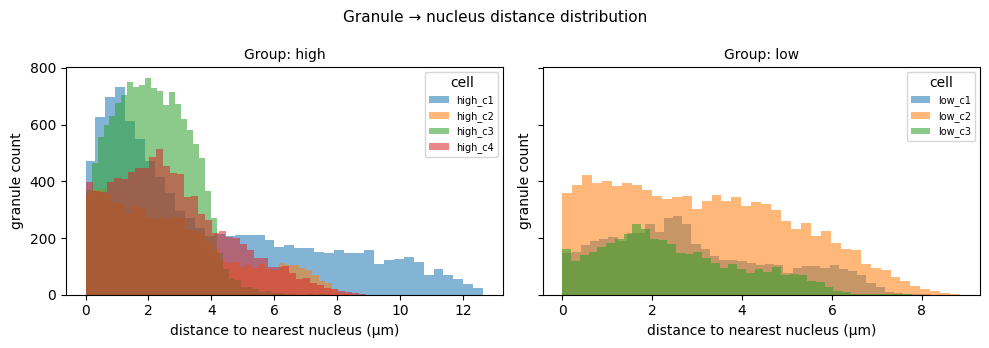

In [6]:
granules = instances[instances.entity_name == "granules"].copy()
dist_col = "distance_to_nucleus_um"

if dist_col not in granules.columns:
    print(f"Column {dist_col!r} not present — available distance columns:")
    print([c for c in granules.columns if c.startswith("distance_")])
else:
    has_groups = "group_id" in granules.columns and granules["group_id"].notna().any()
    groups = sorted(granules["group_id"].dropna().unique()) if has_groups else ["all"]

    fig, axes = plt.subplots(1, len(groups), figsize=(5 * len(groups), 3.5),
                             sharey=True, squeeze=False)
    axes = axes[0]

    for ax, grp_name in zip(axes, groups):
        subset = granules if grp_name == "all" else granules[granules["group_id"] == grp_name]
        for cell_id, cell_grp in subset.groupby("cell_id"):
            vals = cell_grp[dist_col].dropna()
            if len(vals):
                ax.hist(vals, bins=40, alpha=0.55, label=cell_id)
        ax.set_xlabel("distance to nearest nucleus (µm)")
        ax.set_ylabel("granule count")
        ax.set_title(f"Group: {grp_name}", fontsize=10)
        ax.legend(fontsize=7, title="cell")

    fig.suptitle("Granule → nucleus distance distribution", fontsize=11)
    plt.tight_layout()
    plt.show()